In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [4]:
DATA_DIR = Path(r"F:\lab\cptac_prostate\data\v4\CPTAC")
OUTPUT_DIR = Path(r"E:\lab\cptac-prostate\runs\20260402_frag_cptac_tmt_pca")
OUTPUT_DIR.mkdir(exist_ok=True)
print(DATA_DIR.exists(), OUTPUT_DIR.exists())
meta_path = DATA_DIR / "20_MetaData_03_12_2026.csv"

True True


In [5]:
meta = pd.read_csv(meta_path)
meta

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [6]:
meta_include = meta[meta["include_or_excludetumor"] == "Include"]
meta_include

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
0,C3L-07287,C3L.07287.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.342000,0.000000,0.0,0.0,1.0,0.0,0.0,55.333000,0.409000,IR
1,C3L-11156,C3L.11156.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.498000,0.0,0.0,1.0,0.0,0.0,44.167000,0.325000,LR
2,C3L-09494,C3L.09494.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.281000,0.000000,0.0,1.0,0.0,0.0,0.0,123.167000,0.919000,HR
3,CHTN-49141,CHTN.49141.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.420000,0.000000,0.0,1.0,0.0,0.0,0.0,103.833000,0.773000,HR
4,C3L-11095,C3L.11095.T,tumor,Include,Sufficient Purity,ETS,ETS,NaN,ERG,ERG,...,0.000000,0.369000,0.0,0.0,1.0,0.0,0.0,44.667000,0.328000,LR
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,C3L-07872,C3L.07872.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.460832,1.0,0.0,0.0,0.0,0.0,73.666667,0.546366,IR
179,C3L-08642,C3L.08642.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.334840,0.0,0.0,1.0,0.0,0.0,46.166667,0.339599,LR
180,C3L-10399,C3L.10399.T,tumor,Include,Low Purity,NaN,NaN,NaN,ERG,ERG,...,0.000000,0.445334,0.0,0.0,1.0,0.0,0.0,60.000000,0.443609,IR
181,C3L-05301,C3L.05301.T,tumor,Include,Low Purity,NaN,NaN,NaN,ETV1,ETV1,...,0.000000,0.457908,0.0,0.0,1.0,0.0,0.0,45.333333,0.333333,LR


In [7]:
sample_id_col = "common_ID"
purity_map = dict(zip(meta_include[sample_id_col], meta_include["FirstCategory"]))
stage_map = dict(zip(meta_include[sample_id_col], meta_include["stage"]))
gleason_map = dict(zip(meta_include[sample_id_col], meta_include["Grade_Group"]))

In [8]:
meta_exclude = meta[meta["include_or_excludetumor"] == "exclude"]
meta_exclude

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
144,C3L-09492,C3L.09492.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145,C3L-09497,C3L.09497.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
146,C3L-06260,C3L.06260.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147,C3L-06510,C3L.06510.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,C3L-07890,C3L.07890.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
149,C3L-09372,C3L.09372.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
150,C3N-09047,C3N.09047.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
151,C3L-07868,C3L.07868.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152,C3L-09563,C3L.09563.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,C3L-10319,C3L.10319.T,tumor,exclude,No Tumor,NaN,NaN,NaN,NaN,No Tumor,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
meta_normal = meta[meta["include_or_excludetumor"] == "normal"]
meta_normal

,case_id,common_ID,Tissuetype,include_or_excludetumor,FirstCategory,AdditionalSegments,SecondCategory,ThirdCategory,all_drivers,Main_Groups,...,LumB_Pam50,Normal_Pam50,Basal,Her2,LumA,LumB,Normal,agg_rank_raw,agg_rank_scaled,risk_group
111,C3L-07813,C3L.07813.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
112,C3L-06504,C3L.06504.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
113,C3L-06506,C3L.06506.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,C3L-06741,C3L.06741.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,C3L-06890,C3L.06890.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
116,C3L-06901,C3L.06901.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
117,C3L-06743,C3L.06743.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
118,C3L-07607,C3L.07607.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,C3L-06436,C3L.06436.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,C3L-07809,C3L.07809.N,normal,normal,Normal,NaN,NaN,NaN,normal,normal,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
tumors_included = meta_include['common_ID'].tolist()
tumors_excluded = meta_exclude['common_ID'].tolist()
print(len(tumors_included), len(tumors_excluded))

134 16


In [11]:
normals = meta_normal['common_ID'].tolist()
print(len(normals))

33


In [12]:
# data
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"phospho_TMT_ratio",i.stem, re.IGNORECASE) \
         and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE) \
            and not re.search(r"normalized",i.stem, re.IGNORECASE)] 
data_path = files[0]
print(data_path)
header_cols = ["gene_site","Index","SequenceWindow"]
data = pd.read_csv(data_path,sep="\t").set_index(header_cols)
data_nomiss = data.dropna()

F:\lab\cptac_prostate\data\v4\CPTAC\prostate_CPTAC_phospho_TMT_ratio_single_site_MD.tsv


In [13]:
files

[WindowsPath('F:/lab/cptac_prostate/data/v4/CPTAC/prostate_CPTAC_phospho_TMT_ratio_single_site_MD.tsv')]

In [14]:
data

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
M6PR_S267,ENSP00000000412_S267,DDQLGEEsEERDDHL,-0.152653,0.105130,-0.410499,-0.423219,0.270358,-0.189374,-0.337974,0.032672,0.066165,0.085354,...,0.252478,-0.057686,-0.230422,1.183299,0.137987,0.176602,-0.193945,0.002367,0.347335,0.161394
ESRRA_S19,ENSP00000000442_S19,YIKAEPAsPDSPKGS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESRRA_S22,ENSP00000000442_S22,AEPASPDsPKGSSET,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ESRRA_S27,ENSP00000000442_S27,PDSPKGSsETETEPP,0.387958,0.207588,0.085628,0.230611,0.152039,0.135502,-0.548136,0.131133,-0.253944,-0.057385,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FKBP4_S11,ENSP00000001008_S11,EEMKATEsGAQSAPL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DNM1_T852,ENSP00000516205_T852,RKGPASPtRPAAPRP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.042702,-0.074871,0.518712,0.452699,-0.275853,-0.702490,-0.995977,0.746716,0.315820,0.026136
CAMK2D_S349,ENSP00000516208_S349,NKANVVTsPKENIPT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TUBA3FP_S41,ENSP00000516278_S41,GPKADSDsDLETEGA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.137799,-0.296929,0.538734,-0.330404,-0.170727,-0.485082,-0.404717,0.578812,0.075428,-0.393899


In [15]:
data_nomiss

,,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
gene_site,Index,SequenceWindow,,,,,,,,,,,,,,,,,,,,,
M6PR_S267,ENSP00000000412_S267,DDQLGEEsEERDDHL,-0.152653,0.105130,-0.410499,-0.423219,0.270358,-0.189374,-0.337974,0.032672,0.066165,0.085354,...,0.252478,-0.057686,-0.230422,1.183299,0.137987,0.176602,-0.193945,0.002367,0.347335,0.161394
FKBP4_S258,ENSP00000001008_S258,SFEKAKEsWEMNSEE,-0.080313,0.215040,-0.212572,-0.243663,-0.297788,-0.155746,0.191954,-0.219349,1.642965,-0.006126,...,-0.449688,-0.903831,-0.748244,-0.405466,-0.620764,-0.643077,0.458055,-0.952692,-0.502935,0.764775
FKBP4_S453,ENSP00000001008_S453,SNTAGSQsQVETEA-,-0.664965,-0.386701,-0.683407,-1.003484,-0.508349,-0.758670,-0.499116,-0.021148,-0.181385,0.138700,...,-0.364357,-0.811015,-0.914554,-0.444786,-0.178788,-0.311887,-0.053362,-1.103506,-0.307088,-0.386649
CFTR_S737,ENSP00000003084_S737,EPLERRLsLVPDSEQ,-0.384231,-0.932330,-0.836805,-0.714878,-0.660221,0.194315,-1.214076,0.950273,-0.553533,-0.104649,...,0.801556,0.278902,-0.615359,2.598428,0.355969,-0.661561,-0.427716,-0.375639,0.436811,-0.532016
HSPB6_S16,ENSP00000004982_S16,PSWLRRAsAPLPGLS,-0.950869,-0.480455,-0.275935,0.171766,-0.359540,0.000663,-0.179875,-0.144970,-0.527644,-0.330870,...,-1.139613,-1.779075,1.965498,-0.994687,-1.270175,-0.393223,-1.831931,-1.344243,-0.086774,-1.857233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SRRM1_T220,ENSP00000516157_T220,APEKKEKtPELPEPS,-0.059522,-0.127516,-0.409320,-0.590531,0.201572,-0.253919,0.090555,0.149341,0.467441,0.567972,...,0.039659,-0.263828,-0.729216,0.010298,0.034233,0.009183,0.049145,-0.502502,-0.262857,-0.407581
SRRM1_T416,ENSP00000516157_T416,PKTRHsPtPQQSNRT,0.123060,-0.122870,-0.073792,-0.671631,-0.313469,-0.183969,-0.113390,0.094610,0.559364,0.479827,...,0.017260,-0.265258,-1.076544,-0.380144,-0.104944,-0.131461,0.127151,-0.603184,-0.289414,-0.497071
SRRM1_T628,ENSP00000516157_T628,SPPPKRRtAsPPPPP,-0.338267,-0.370862,-0.400699,-0.715744,0.368004,-0.101604,0.177564,-0.062989,0.173630,0.104672,...,-0.051742,-0.471699,-0.270337,0.173586,0.186290,-0.195923,0.125274,-0.450014,-0.183483,-0.182057


In [16]:
samples = data.columns.tolist()
len(samples)

178

In [17]:
set_tumors_included = set(tumors_included)
set_tumors_excluded = set(tumors_excluded)
set_normals = set(normals)
set_data = set(samples)
print((len(set_tumors_included), len(set_tumors_excluded), len(set_normals), len(set_data)))

(134, 16, 33, 178)


In [18]:
set_data - set_tumors_included - set_tumors_excluded - set_normals

{'C3L.06436.T',
 'C3L.07292.N',
 'C3L.07606.N',
 'C3L.08546.T',
 'C3L.09345.T',
 'C3L.09373.T',
 'C3L.09793.T',
 'C3L.09832.T',
 'C3L.09972.T',
 'C3L.10301.T',
 'CHTN.47295.T'}

<Axes: >

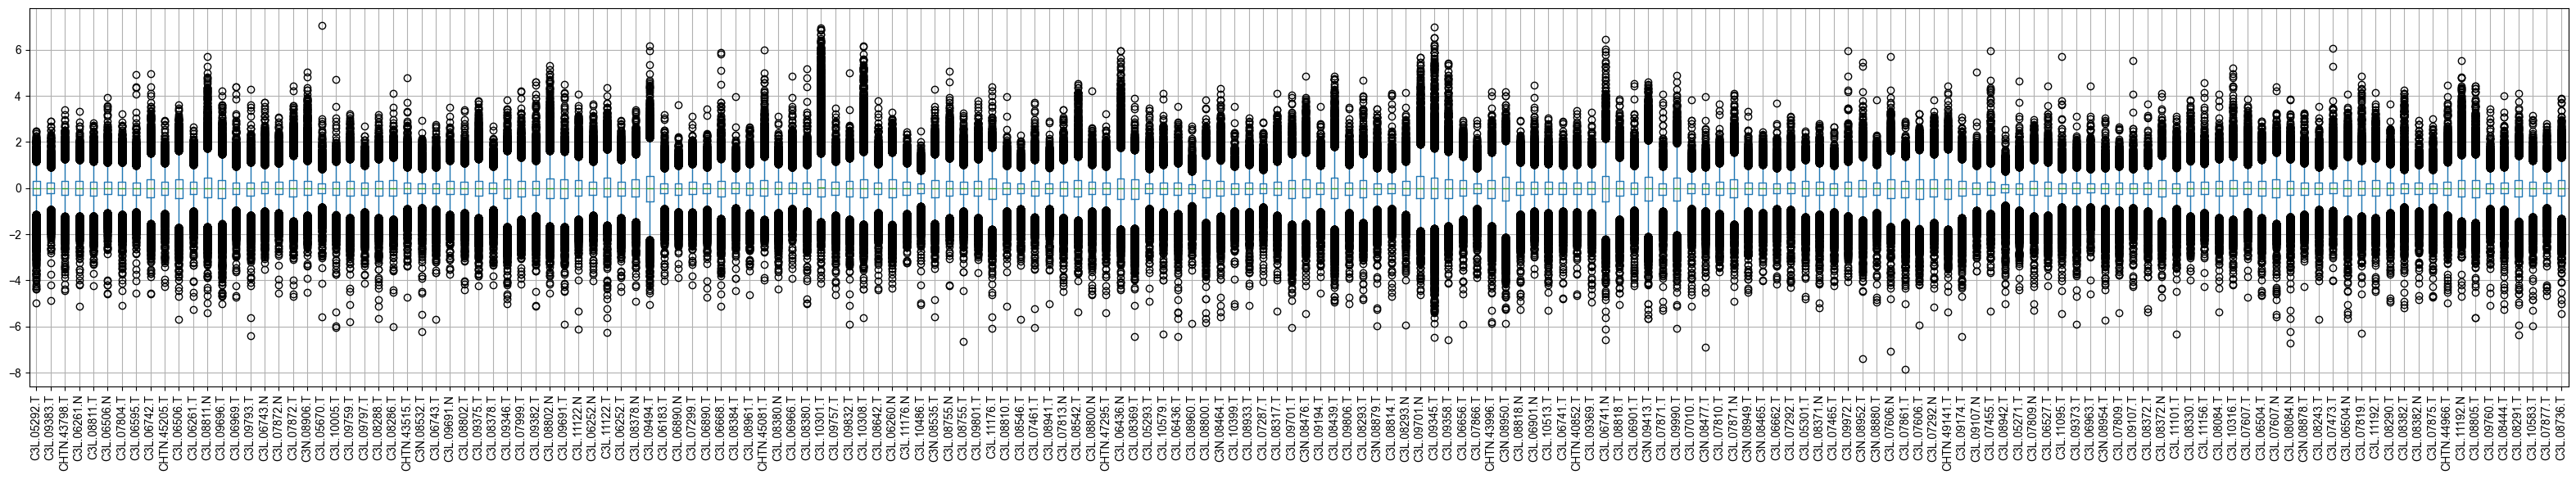

In [19]:
data.boxplot(figsize=(40,6), rot=90)

In [20]:
from omicsone_streamlit.plots.pca import plot_pca1

In [21]:
print(len(tumors_included), len(normals))

134 33


In [22]:
len(set(data.columns) & set(tumors_included))

134

In [31]:
tag = "phospho"

In [32]:
xlim = (-60,60)
ylim = (-60,60)

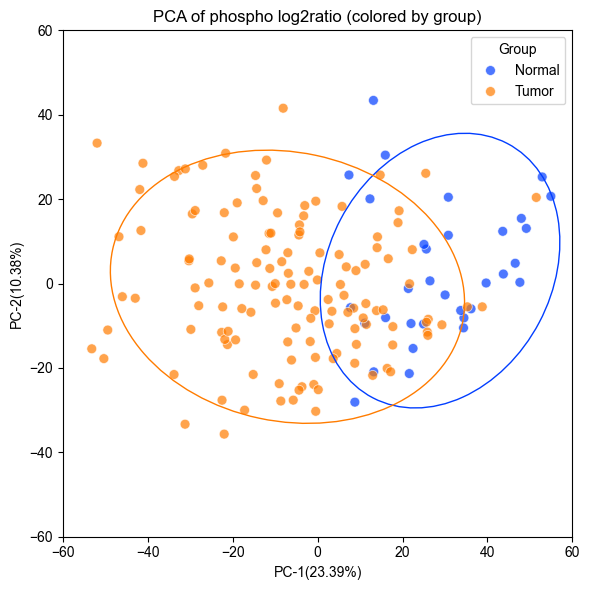

In [33]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = "Tumor"
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2 = data_nomiss.T.loc[tumors_included + normals,:]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} log2ratio (colored by group)")

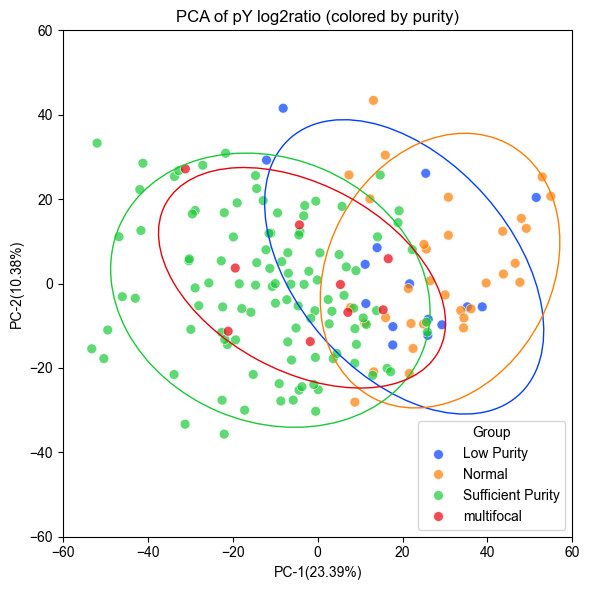

In [34]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = purity_map.get(i, "Tumor")
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title="PCA of pY log2ratio (colored by purity)")

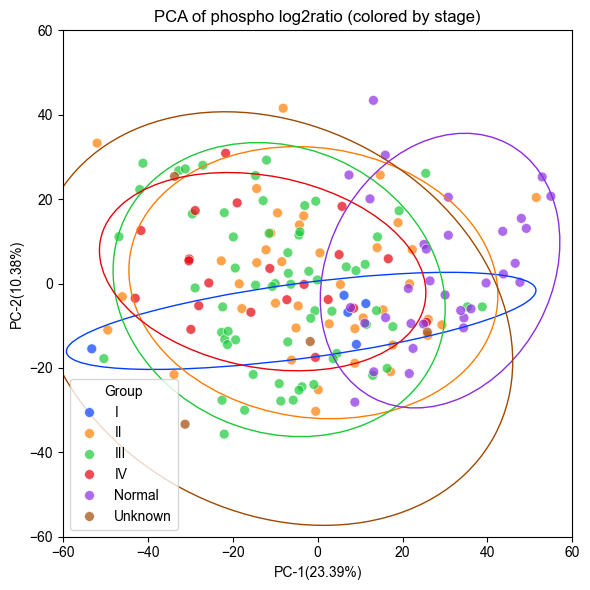

In [35]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = re.sub("[ABC]",'',stage_map.get(i, "Tumor"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} log2ratio (colored by stage)")

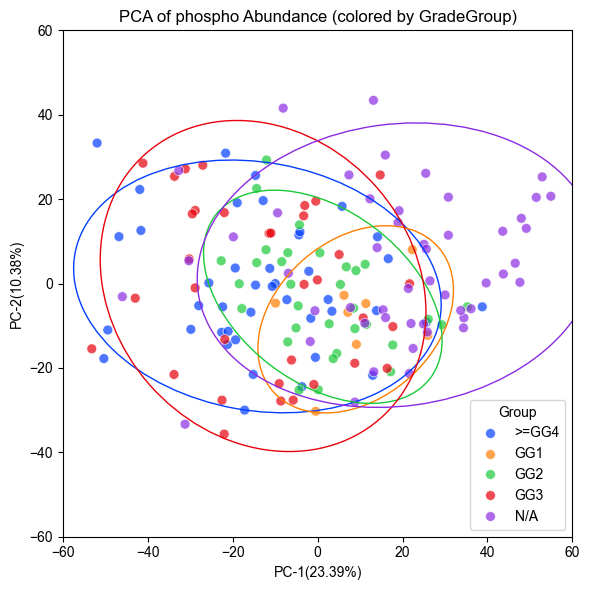

In [36]:
group_map = dict()
for i in tumors_included + normals:
    # print(i)
    if i in tumors_included:
        group_map[i] = str(gleason_map.get(i, "N/A"))
    elif i in normals:
        group_map[i] = "Normal"
    else:
        group_map[i] = "Other"
for i in group_map:
    group_map[i] = 'N/A' if not re.search("GG", group_map[i]) else group_map[i]
data2['Group'] = data2.index.map(group_map)
data2 = data2.sort_values(by='Group')
fig,pca = plot_pca1(data2, n=1, palette='bright', 
                    xlim=xlim, ylim=ylim, figsize=(6,6),
                    title=f"PCA of {tag} Abundance (colored by GradeGroup)")